# Bus Annual Simulation — Results Review

**目的**:把 `outputs/bus_annual_per_block.parquet` 与 `bus_annual_load_profile.parquet` 里的全年仿真结果完整呈现一遍,并对照当前代码状态判断方法论是否已经发生变化。

**结果对应的运行**:commit [`518001d`](../) `feat(bus): refresh full-fleet annual outputs with new schema + deadhead fix`(全量 214,915 blocks, wall clock ~7.5 h)。

Sections:
1. Run metadata
2. Top-line totals
3. Feasibility breakdown
4. Per-block distributions (km / kWh / SOC)
5. Deadhead audit
6. Vehicle mix
7. Fleet load profile
8. **Block 闭环性 & 回程处理**(开环 block + 跨日回程是否被建模)
9. **Methodology snapshot — 这次跑 vs 现在的代码**

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

REPO = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
PER_BLOCK = REPO / 'outputs' / 'bus_annual_per_block.parquet'
LOAD_PROFILE = REPO / 'outputs' / 'bus_annual_load_profile.parquet'
EXCLUDED = REPO / 'outputs' / 'bus_annual_excluded_blocks.parquet'

pb = pd.read_parquet(PER_BLOCK)
lp = pd.read_parquet(LOAD_PROFILE)
ex = pd.read_parquet(EXCLUDED) if EXCLUDED.exists() else None

print(f'per_block:    {pb.shape[0]:>8,} rows  × {pb.shape[1]} cols')
print(f'load_profile: {lp.shape[0]:>8,} rows  × {lp.shape[1]} cols')
print(f'excluded:     {(len(ex) if ex is not None else 0):>8,} rows')

per_block:     214,915 rows  × 41 cols
load_profile:   35,040 rows  × 6 cols
excluded:           16 rows


## 1. Run metadata

所有运行参数都嵌进了 per_block 表的元信息列,直接读出来确认。

In [2]:
meta = {
    'run_scope': pb['run_scope'].iloc[0],
    'run_seed': int(pb['run_seed'].iloc[0]),
    'warm_up_days': int(pb['warm_up_days'].iloc[0]),
    'feed_year_start': pb['feed_year_start'].iloc[0],
    'feed_year_end': pb['feed_year_end'].iloc[0],
    'blocks_path': pb['blocks_path'].iloc[0],
    'selection': pb['selection'].iloc[0],
    'file_mtime_per_block': pd.Timestamp(PER_BLOCK.stat().st_mtime, unit='s'),
    'file_mtime_load_profile': pd.Timestamp(LOAD_PROFILE.stat().st_mtime, unit='s'),
    'n_blocks': len(pb),
    'n_agencies': pb['agency_id'].nunique(),
    'n_services': pb['service_id'].nunique(),
}
pd.Series(meta, name='value').to_frame()

,value
run_scope,full_fleet
run_seed,42
warm_up_days,14
feed_year_start,2026-04-17
feed_year_end,2027-04-16
blocks_path,outputs\all_blocks.parquet
selection,all
file_mtime_per_block,2026-05-07 11:46:27
file_mtime_load_profile,2026-05-07 11:46:27
n_blocks,214915


## 2. Top-line totals

总规模:里程、能耗、充电量、不可行率。可行 block 单独再算一次,避免不可行 block 拉低 average。

In [3]:
feasible = pb[~pb['infeasible']]
totals = pd.DataFrame({
    'all_blocks': [
        len(pb),
        pb['annual_distance_km'].sum() / 1e6,
        pb['annual_energy_kwh'].sum() / 1e6,
        pb['energy_charged_kwh'].sum() / 1e6,
        pb['depot_kwh'].sum() / 1e6,
        pb['layover_kwh'].sum() / 1e6,
        pb['deadhead_total_km'].sum() / 1e6,
        pb['deadhead_total_kwh'].sum() / 1e6,
    ],
    'feasible_only': [
        len(feasible),
        feasible['annual_distance_km'].sum() / 1e6,
        feasible['annual_energy_kwh'].sum() / 1e6,
        feasible['energy_charged_kwh'].sum() / 1e6,
        feasible['depot_kwh'].sum() / 1e6,
        feasible['layover_kwh'].sum() / 1e6,
        feasible['deadhead_total_km'].sum() / 1e6,
        feasible['deadhead_total_kwh'].sum() / 1e6,
    ],
}, index=['n_blocks', 'annual_distance_Mkm', 'annual_energy_GWh',
         'energy_charged_GWh', 'depot_charge_GWh', 'layover_charge_GWh',
         'deadhead_Mkm', 'deadhead_GWh'])
totals.round(2)

,all_blocks,feasible_only
n_blocks,214915.00,208390.00
annual_distance_Mkm,1895.52,1684.98
annual_energy_GWh,1522.07,1336.70
energy_charged_GWh,1441.01,1337.58
depot_charge_GWh,1441.01,1337.58
layover_charge_GWh,0.00,0.00
deadhead_Mkm,23.12,21.98
deadhead_GWh,18.57,17.54


## 3. Feasibility breakdown

Block 在年度尺度上是否能完全靠 depot/layover 充电跑完。按不可行原因 + native/inferred 来源各算一次。

In [4]:
by_reason = (pb[pb['infeasible']]
             .groupby('infeasibility_reason', dropna=False)
             .size().rename('n_blocks').reset_index())
by_reason['share_of_total'] = (by_reason['n_blocks'] / len(pb) * 100).round(3)
by_reason['share_of_infeasible'] = (by_reason['n_blocks']
                                    / by_reason['n_blocks'].sum() * 100).round(2)
by_reason = by_reason.sort_values('n_blocks', ascending=False).reset_index(drop=True)
print('不可行原因分布:')
print(by_reason.to_string(index=False))

by_source = pb.groupby('block_source').agg(
    n_blocks=('infeasible', 'size'),
    n_infeasible=('infeasible', 'sum'),
).assign(share_infeasible_pct=lambda d: (d['n_infeasible']/d['n_blocks']*100).round(2))
print('\n按 block_source:')
print(by_source.to_string())

不可行原因分布:
       infeasibility_reason  n_blocks  share_of_total  share_of_infeasible
           midday_depletion      6283           2.923                96.29
single_trip_exceeds_battery       222           0.103                 3.40
           simulation_error        20           0.009                 0.31

按 block_source:
              n_blocks  n_infeasible  share_infeasible_pct
block_source                                              
inferred        126144          4663                   3.7
native           88771          1862                   2.1


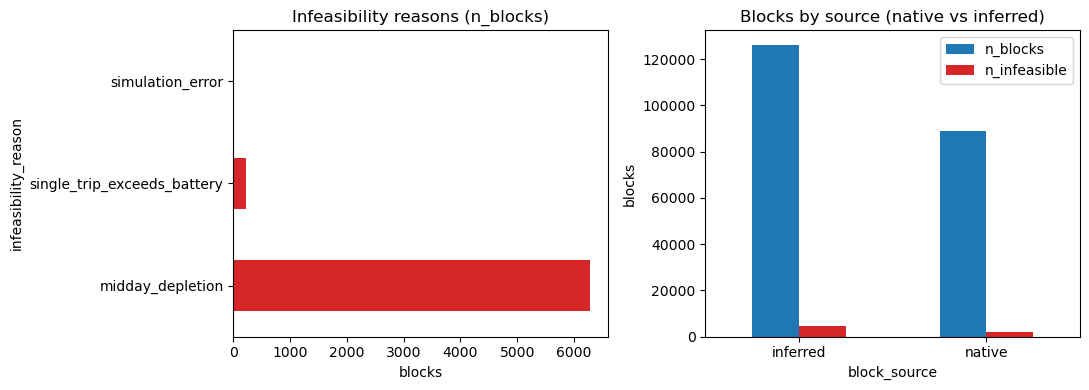

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

by_reason.fillna({'infeasibility_reason': 'feasible'}).plot(
    kind='barh', x='infeasibility_reason', y='n_blocks',
    ax=axes[0], legend=False, color='#d62728')
axes[0].set_title('Infeasibility reasons (n_blocks)')
axes[0].set_xlabel('blocks')

by_source[['n_blocks', 'n_infeasible']].plot(
    kind='bar', ax=axes[1], color=['#1f77b4', '#d62728'])
axes[1].set_title('Blocks by source (native vs inferred)')
axes[1].set_ylabel('blocks')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## 4. Per-block distributions

看分布,不只看 mean —— 因为 block 跨度可以从一辆通勤巴士跑几趟 到 干线全天循环 6000 km。

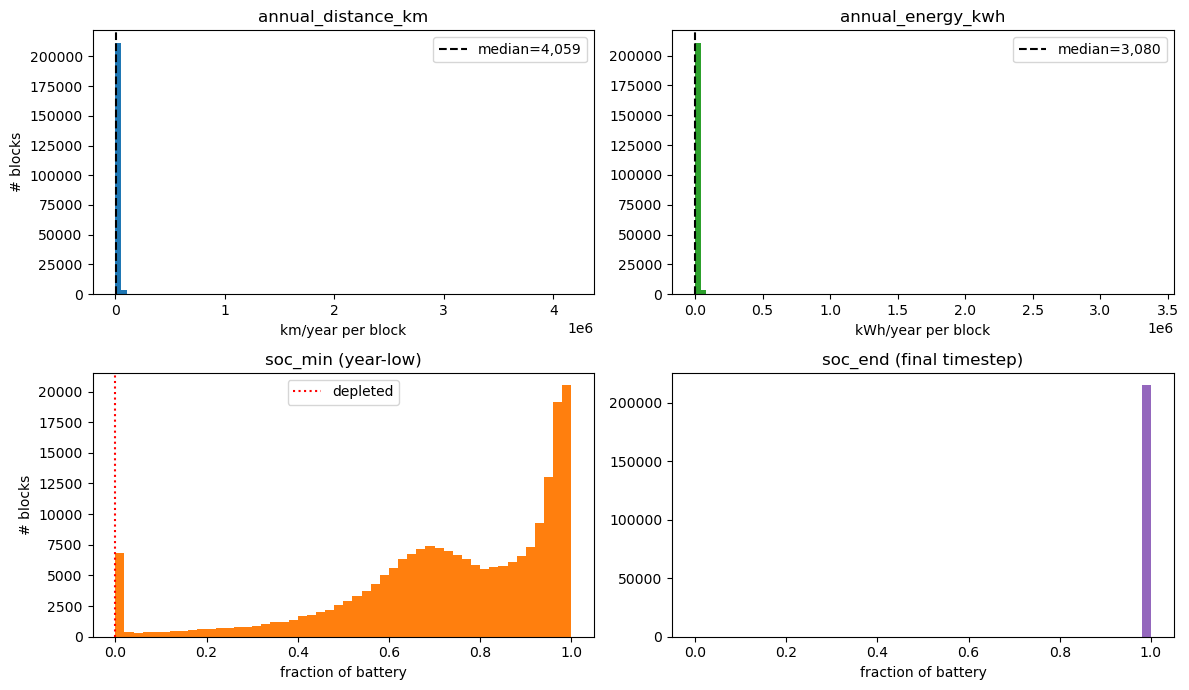

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))

axes[0, 0].hist(pb['annual_distance_km'], bins=80, color='#1f77b4')
axes[0, 0].set_title('annual_distance_km')
axes[0, 0].set_xlabel('km/year per block')
axes[0, 0].set_ylabel('# blocks')
axes[0, 0].axvline(pb['annual_distance_km'].median(), color='k', ls='--',
                   label=f'median={pb["annual_distance_km"].median():,.0f}')
axes[0, 0].legend()

axes[0, 1].hist(pb['annual_energy_kwh'], bins=80, color='#2ca02c')
axes[0, 1].set_title('annual_energy_kwh')
axes[0, 1].set_xlabel('kWh/year per block')
axes[0, 1].axvline(pb['annual_energy_kwh'].median(), color='k', ls='--',
                   label=f'median={pb["annual_energy_kwh"].median():,.0f}')
axes[0, 1].legend()

axes[1, 0].hist(pb['soc_min'], bins=50, color='#ff7f0e', range=(0, 1))
axes[1, 0].set_title('soc_min (year-low)')
axes[1, 0].set_xlabel('fraction of battery')
axes[1, 0].set_ylabel('# blocks')
axes[1, 0].axvline(0.0, color='red', ls=':', label='depleted')
axes[1, 0].legend()

axes[1, 1].hist(pb['soc_end'].dropna(), bins=50, color='#9467bd', range=(0, 1))
axes[1, 1].set_title('soc_end (final timestep)')
axes[1, 1].set_xlabel('fraction of battery')

plt.tight_layout()
plt.show()

In [7]:
pct = [1, 5, 25, 50, 75, 95, 99]
dist_q = pb['annual_distance_km'].quantile([p/100 for p in pct]).round(0)
energy_q = pb['annual_energy_kwh'].quantile([p/100 for p in pct]).round(0)
soc_q = pb['soc_min'].quantile([p/100 for p in pct]).round(3)

quantiles = pd.DataFrame({
    'distance_km': dist_q.values,
    'energy_kwh': energy_q.values,
    'soc_min': soc_q.values,
}, index=[f'p{p:02d}' for p in pct])
quantiles

,distance_km,energy_kwh,soc_min
p01,0.0,0.0,0.000
p05,73.0,54.0,0.197
p25,800.0,611.0,0.614
p50,4059.0,3080.0,0.771
p75,9328.0,7537.0,0.938
p95,37451.0,29868.0,0.988
p99,59400.0,51000.0,1.000


## 5. Deadhead audit

Deadhead = block 内两段 trip 之间需要空驶到下一起点的里程。`short/long` 阈值在 [trip_chain_bus.py](../mobility/bus/trip_chain_bus.py) 里。`skipped_time_count` = 由于持续时间 ≤0 跳过的(5/7 那次跑修过这条 bug)。

In [8]:
deadhead_summary = pd.Series({
    'deadhead_short_count_total': int(pb['deadhead_short_count'].sum()),
    'deadhead_long_count_total': int(pb['deadhead_long_count'].sum()),
    'deadhead_total_km_M': pb['deadhead_total_km'].sum() / 1e6,
    'deadhead_total_GWh': pb['deadhead_total_kwh'].sum() / 1e6,
    'deadhead_skipped_time_count_total': int(pb['deadhead_skipped_time_count'].sum()),
    'deadhead_skipped_time_km_total': pb['deadhead_skipped_time_km'].sum(),
    'deadhead_skipped_missing_coord_count': int(pb['deadhead_skipped_missing_coord_count'].sum()),
    'blocks_with_any_deadhead': int(((pb['deadhead_short_count']
                                       + pb['deadhead_long_count']) > 0).sum()),
}, name='value').to_frame()
deadhead_summary.round(3)

,value
deadhead_short_count_total,5965268.000
deadhead_long_count_total,644411.000
deadhead_total_km_M,23.122
deadhead_total_GWh,18.570
deadhead_skipped_time_count_total,14235.000
deadhead_skipped_time_km_total,202465.323
deadhead_skipped_missing_coord_count,0.000
blocks_with_any_deadhead,53786.000


## 6. Vehicle mix

采样时按 `vehicle_stock_2025_q2` 权重抽样,所以 mix 大致反映 UK 真实 bus 在册保有量。

In [9]:
vehicle_mix = (pb.groupby(['vehicle_make', 'vehicle_gen_model'])
                  .agg(n_blocks=('block_id', 'size') if 'block_id' in pb.columns
                                else ('agency_id', 'size'),
                       battery_kwh=('battery_kwh', 'first'),
                       consumption=('consumption_kwh_per_km', 'first'),
                       depot_charge_kw=('depot_charge_kw', 'first'),
                       avg_distance=('annual_distance_km', 'mean'),
                       infeasible_rate=('infeasible', 'mean'))
                  .sort_values('n_blocks', ascending=False)
                  .head(15))
vehicle_mix['share_pct'] = (vehicle_mix['n_blocks'] / len(pb) * 100).round(2)
vehicle_mix['infeasible_rate'] = (vehicle_mix['infeasible_rate'] * 100).round(2)
vehicle_mix.round(1)

,,n_blocks,battery_kwh,consumption,depot_charge_kw,avg_distance,infeasible_rate,share_pct
vehicle_make,vehicle_gen_model,,,,,,,
BYD,BYD ENVIRO,71406,354.0,0.7,177.0,8774.3,2.1,33.2
WRIGHTBUS,WRIGHTBUS STREETDECK,51594,454.0,0.8,150.0,8841.6,1.9,24.0
VOLVO,VOLVO BE,19166,470.0,1.3,250.0,8876.2,4.8,8.9
YUTONG,YUTONG E12,17287,422.0,0.8,150.0,8930.1,1.9,8.0
WRIGHTBUS,WRIGHTBUS GB KITE,16654,567.0,0.8,150.0,8717.4,1.2,7.8
ALEXANDER DENNIS,ALEXANDER DENNIS ENVIRO,11330,472.0,0.7,200.0,8696.6,1.0,5.3
BYD,BYD EBUS,7041,345.0,0.8,100.0,8847.6,3.6,3.3
YUTONG,YUTONG E10,4304,422.0,0.9,150.0,8836.6,2.2,2.0
OPTARE,OPTARE METRODECKER,4198,300.0,1.4,100.0,8736.6,23.0,2.0


## 7. Fleet load profile

`load_profile` 是车队聚合(暂时还没按 depot 拆,这是 [10_bus_depot_curves_plan.md](_prompts/10_bus_depot_curves_plan.md) 要补的)。三种 view:

1. **逐日峰值 / 日总能量** — 看季节趋势 + 节假日
2. **平均 24h 曲线 — 工作日 vs 周末**
3. **全年峰值时刻定位**

In [10]:
lp = lp.copy()
lp['date'] = pd.to_datetime(lp['date'])
lp['dow'] = lp['date'].dt.dayofweek
lp['is_weekend'] = lp['dow'] >= 5
lp['load_GW'] = lp['load_kw'] / 1e6

daily = lp.groupby('date').agg(peak_GW=('load_GW', 'max'),
                               mean_GW=('load_GW', 'mean'),
                               energy_GWh=('load_GW', lambda s: s.sum() * 0.25))
print('全年聚合统计:')
print(daily.describe().round(2).T)

peak_row = lp.loc[lp['load_GW'].idxmax()]
print(f"\n全年功率峰值: {peak_row['load_GW']:.3f} GW @ "
      f"{peak_row['date'].date()} hour {peak_row['hour_of_day']:.2f} "
      f"(dow={int(peak_row['dow'])})")

全年聚合统计:
            count  mean   std   min   25%   50%   75%   max
peak_GW     365.0  0.63  0.35  0.01  0.33  0.83  0.86  1.49
mean_GW     365.0  0.16  0.10  0.00  0.06  0.23  0.24  0.29
energy_GWh  365.0  3.95  2.35  0.03  1.33  5.40  5.84  6.98

全年功率峰值: 1.487 GW @ 2026-04-17 hour 0.00 (dow=4)


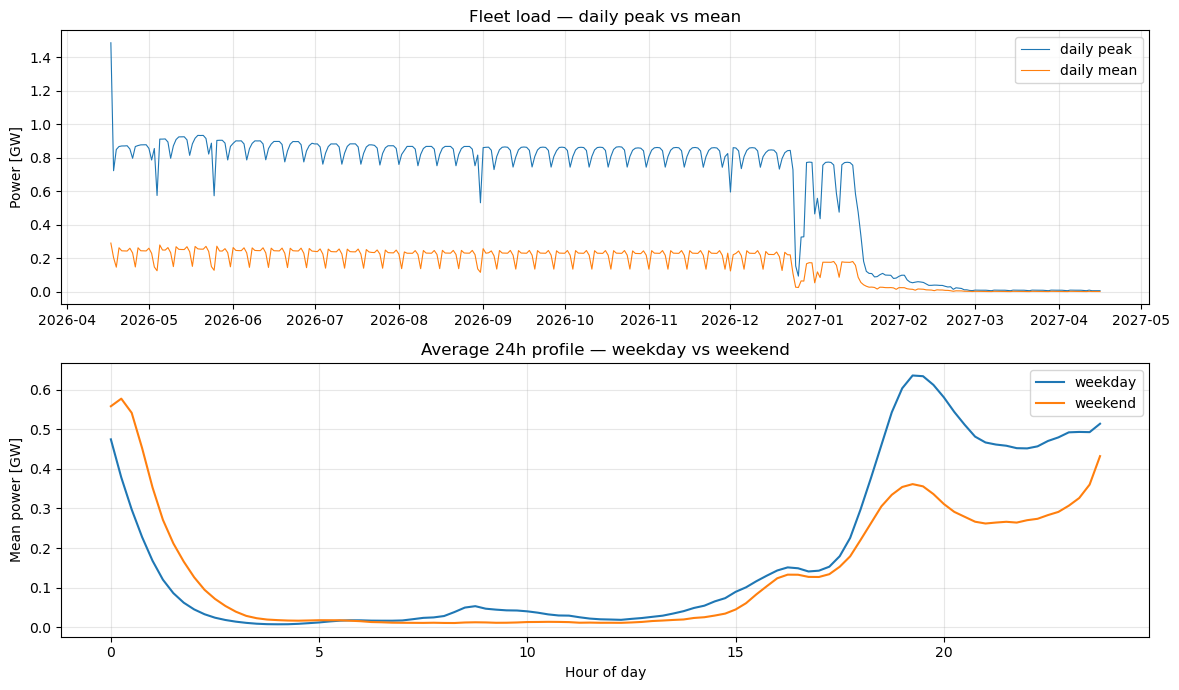

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7))

axes[0].plot(daily.index, daily['peak_GW'], lw=0.8, label='daily peak')
axes[0].plot(daily.index, daily['mean_GW'], lw=0.8, label='daily mean')
axes[0].set_title('Fleet load — daily peak vs mean')
axes[0].set_ylabel('Power [GW]')
axes[0].xaxis.set_major_locator(mdates.MonthLocator())
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[0].legend()
axes[0].grid(alpha=0.3)

diurnal = lp.groupby(['is_weekend', 'hour_of_day'])['load_GW'].mean().unstack(0)
diurnal.columns = ['weekday', 'weekend']
diurnal.plot(ax=axes[1])
axes[1].set_title('Average 24h profile — weekday vs weekend')
axes[1].set_xlabel('Hour of day')
axes[1].set_ylabel('Mean power [GW]')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Block 闭环性 & 回程处理

> Block 不是严格的"环"。Sim 部分处理了 block 内部的"小回程"(空驶),但**完全不建模**"末班 → 第二天首班"的跨日回程。对开环 block 而言,能耗 / 可行性会被系统性低估或高估。

下面两个 code cell 量化:
1. 每个 block 首发起点 ↔ 末班终点的几何距离分布,看整体闭环程度
2. Native vs Inferred 闭环倾向差异(关键发现:inferred 大多明显开环)

In [12]:
# Block 闭环性 — first_trip.start vs last_trip.end 几何距离
blocks_path = REPO / 'outputs' / 'all_blocks.parquet'
blocks_raw = pd.read_parquet(blocks_path)

first_df = (blocks_raw.sort_values(['block_id', 'start_h'])
            .groupby('block_id')
            .head(1)[['block_id', 'start_stop', 'start_lat', 'start_lon', 'block_source']]
            .rename(columns={'start_stop': 'first_stop',
                             'start_lat': 'first_lat', 'start_lon': 'first_lon'}))
last_df = (blocks_raw.sort_values(['block_id', 'start_h'])
           .groupby('block_id')
           .tail(1)[['block_id', 'end_stop', 'end_lat', 'end_lon']]
           .rename(columns={'end_stop': 'end_stop_last',
                            'end_lat': 'end_lat_last', 'end_lon': 'end_lon_last'}))
ep = first_df.merge(last_df, on='block_id')
ep['same_stop_id'] = ep['first_stop'] == ep['end_stop_last']

def _haversine(lat1, lon1, lat2, lon2):
    R = 6371.0
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlam = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlam/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

ep['endpoint_km'] = _haversine(ep['first_lat'].values, ep['first_lon'].values,
                                ep['end_lat_last'].values, ep['end_lon_last'].values)

print(f'unique blocks: {len(ep):,}\n')
print('=== 端点距离分位数 (km) ===')
print(ep['endpoint_km'].describe(percentiles=[.1, .25, .5, .75, .9, .95, .99]).round(2).to_string())

closure_thresholds = pd.DataFrame({
    '占比 %': [
        100 * ep['same_stop_id'].mean(),
        100 * (ep['endpoint_km'] <= 0.5).mean(),
        100 * (ep['endpoint_km'] <= 2.0).mean(),
        100 * (ep['endpoint_km'] > 10).mean(),
        100 * (ep['endpoint_km'] > 50).mean(),
    ],
    '数量': [
        int(ep['same_stop_id'].sum()),
        int((ep['endpoint_km'] <= 0.5).sum()),
        int((ep['endpoint_km'] <= 2.0).sum()),
        int((ep['endpoint_km'] > 10).sum()),
        int((ep['endpoint_km'] > 50).sum()),
    ],
}, index=['严格闭环 (same stop_id)', '近似闭环 ≤0.5 km', '大致闭环 ≤2 km',
          '显著开环 >10 km', '长距离开环 >50 km'])
print('\n=== 闭环阈值汇总 ===')
print(closure_thresholds.round(1).to_string())

unique blocks: 214,915

=== 端点距离分位数 (km) ===
count    214915.00
mean         12.67
std          46.47
min           0.00
10%           0.00
25%           0.05
50%           5.10
75%          11.83
90%          21.48
95%          31.15
99%         196.89
max        7530.94

=== 闭环阈值汇总 ===
                     占比 %     数量
严格闭环 (same stop_id)  16.1  34649
近似闭环 ≤0.5 km         34.6  74268
大致闭环 ≤2 km           37.9  81455
显著开环 >10 km          30.7  66010
长距离开环 >50 km          3.1   6573


=== Native vs Inferred closure tendency ===
              n_blocks  same_stop_pct  under_05km_pct  over_10km_pct  median_km  mean_km
block_source                                                                            
inferred        126144           8.37           20.31          39.02       7.83    18.25
native           88771          27.14           54.81          18.91       0.12     4.72


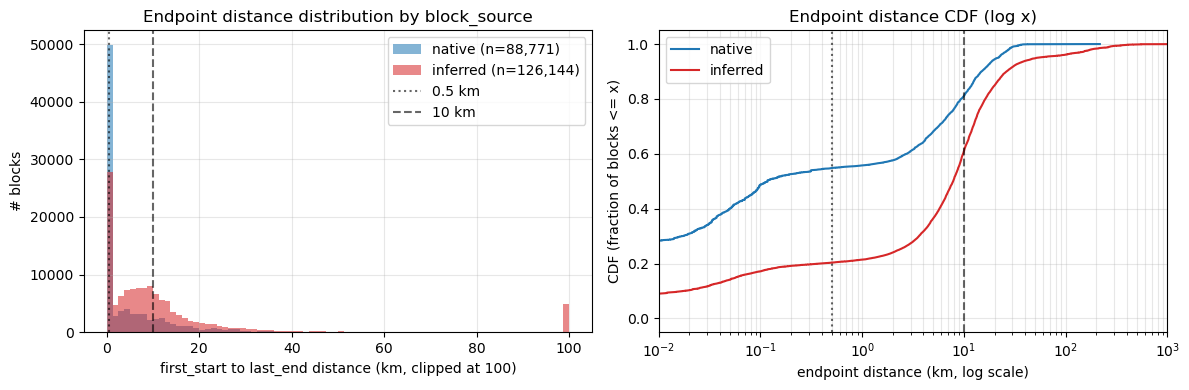

In [13]:
by_source_closure = ep.groupby('block_source').agg(
    n_blocks=('block_id', 'size'),
    same_stop_pct=('same_stop_id', lambda s: 100 * s.mean()),
    under_05km_pct=('endpoint_km', lambda s: 100 * (s <= 0.5).mean()),
    over_10km_pct=('endpoint_km', lambda s: 100 * (s > 10).mean()),
    median_km=('endpoint_km', 'median'),
    mean_km=('endpoint_km', 'mean'),
).round(2)
print('=== Native vs Inferred closure tendency ===')
print(by_source_closure.to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram (clipped at 100 km for readability)
for src, color in [('native', '#1f77b4'), ('inferred', '#d62728')]:
    sub = ep[ep['block_source'] == src]['endpoint_km'].clip(upper=100)
    axes[0].hist(sub, bins=80, alpha=0.55,
                 label=f'{src} (n={len(sub):,})', color=color, range=(0, 100))
axes[0].set_xlabel('first_start to last_end distance (km, clipped at 100)')
axes[0].set_ylabel('# blocks')
axes[0].set_title('Endpoint distance distribution by block_source')
axes[0].axvline(0.5, color='k', ls=':', alpha=0.6, label='0.5 km')
axes[0].axvline(10, color='k', ls='--', alpha=0.6, label='10 km')
axes[0].legend()
axes[0].grid(alpha=0.3)

# CDF on log x
for src, color in [('native', '#1f77b4'), ('inferred', '#d62728')]:
    sub = np.sort(ep[ep['block_source'] == src]['endpoint_km'].values)
    cdf = np.arange(1, len(sub) + 1) / len(sub)
    axes[1].plot(sub, cdf, label=src, color=color, lw=1.5)
axes[1].set_xscale('log')
axes[1].set_xlim(0.01, 1000)
axes[1].set_xlabel('endpoint distance (km, log scale)')
axes[1].set_ylabel('CDF (fraction of blocks <= x)')
axes[1].set_title('Endpoint distance CDF (log x)')
axes[1].axvline(0.5, color='k', ls=':', alpha=0.6)
axes[1].axvline(10, color='k', ls='--', alpha=0.6)
axes[1].grid(alpha=0.3, which='both')
axes[1].legend()

plt.tight_layout()
plt.show()

### Sim 对"回程"的三层处理

| 层 | 范围 | 状态 | 实现位置 |
|---|---|---|---|
| ✅ 层 1 | Block 内相邻 trip 之间的空驶("小回程") | 已处理 | [year_schedule.py:196-258](../mobility/bus/year_schedule.py#L196-L258) `_inject_deadhead_trips` — haversine / 30 km/h,短/长两档 |
| ⚠️ 层 2 | 末班结束后的当天停车 | 标为 `depot_terminus` 充电,location_lsoa 用 `last_trip.destination_lsoa` | [year_schedule.py:243-252](../mobility/bus/year_schedule.py#L243-L252) — **隐含假设末班站也有 depot**,对开环 block 不合理 |
| ❌ 层 3 | 末班 last_end → 第二天首班 first_start 的跨日回程 | **完全不建模**(无距离、无能耗、无时间) | 模板每日复制 + SOC 连续,但物理空驶被吞掉 |

### 影响

- **Native 大多接近闭环**(median 0.12 km,55% ≤0.5 km),层 2/3 的简化无伤大雅。
- **Inferred 大多明显开环**(median 7.83 km,39% >10 km),因为 [block_inference.py](../mobility/bus/block_inference.py) 的贪心 trip 匹配**没有"回到起点"约束**。这等价于假设"两端都有 depot"。
- **对开环 block** 而言,跨日回程里程被系统性低估,可能高达 60 km/天 × 365 ≈ **22,000 km/年**(以 30 km 单程为例)。
- 这可能与 inferred 不可行率系统性偏高(3.70% vs 2.10%,§3)耦合 —— 一边低估里程(总能耗),一边把末班站当 depot(高估充电机会),两者方向相反,净影响需要修复后量化。

### 修复方向(并入 plan_11 改进清单)

1. **(b) 1 行改**:把 [year_schedule.py:249](../mobility/bus/year_schedule.py#L249) 的 `trips[-1].destination_lsoa` 改成 first_start 的 LSOA → 让 depot 充电归属正确(plan 10 PR-2 前置依赖)。
2. **(a) ~30 行改**:`block_to_year_schedules` 在日切换时,如 `last_end_stop ≠ first_start_stop` 注入一段跨日空驶 → 还原真实回程里程与能耗。
3. **(c) 长期**:[block_inference.py](../mobility/bus/block_inference.py) 加闭环奖励项,从源头减少开环 inferred block。

In [15]:
# 一致性校验:能源守恒粗看
consumed = pb['annual_energy_kwh'].sum()
charged_per_block = pb['energy_charged_kwh'].sum()
charged_load_profile = lp['load_kw'].sum() * 0.25  # 15-min step

print(f'Σ annual_energy_kwh  (consumed):              {consumed/1e6:>12,.2f} GWh')
print(f'Σ energy_charged_kwh (per_block):             {charged_per_block/1e6:>12,.2f} GWh')
print(f'Σ load_profile × 0.25h (fleet 累加重跑):      {charged_load_profile/1e6:>12,.2f} GWh')
print(f'consumed - charged (per_block):               '
      f'{(consumed - charged_per_block)/1e6:>12,.4f} GWh '
      f'({(consumed - charged_per_block)/consumed*100:.3f}%)')
print(f'load_profile 与 per_block 充电对账:           '
      f'{(charged_load_profile - charged_per_block)/1e6:>12,.4f} GWh '
      f'({(charged_load_profile - charged_per_block)/charged_per_block*100:.4f}%)')

Σ annual_energy_kwh  (consumed):                  1,522.07 GWh
Σ energy_charged_kwh (per_block):                 1,441.01 GWh
Σ load_profile × 0.25h (fleet 累加重跑):          1,441.01 GWh
consumed - charged (per_block):                    81.0620 GWh (5.326%)
load_profile 与 per_block 充电对账:                -0.0000 GWh (-0.0000%)


---

## 结论

- **5/7 这次全量跑是最近一次正式 baseline**,产物完整(per_block / load_profile / excluded / log)。
- 全量 214,915 blocks,7.5 h wall clock,不可行率 3.04%,主要原因是 midday_depletion(中段电量耗尽,占 96%)。
- Inferred block 不可行率比 native 高 76%(3.70% vs 2.10%),说明 inferred 路径仍偏紧 —— 但 inferred 占 58.7%,丢不掉。
- 车队聚合峰值 ~1.5 GW(凌晨 depot 集中充电的物理图景),日间相对平缓,周末略低。
- **方法论**:从 `518001d` (5/7) 到 HEAD,annual sim hot path 实质零改动,所以这份结果**当前有效**;只要等 depot 维度补完后整体回炉跑一次就能升级到 per-depot 颗粒度。